In [1]:
# Imports

import helpers.helper_functions as hf
import mne
import os.path as op
from mne.channels import combine_channels
import pandas as pd
from mne.beamformer import make_lcmv, apply_lcmv_epochs
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert
import helpers.test_circ_plot as circ_plot
import gc
import helpers.stc_helper as stc_helper
import time
from pycircstat2.hypothesis import rayleigh_test

ss = hf.settings_dict()

In [2]:
subject_index = 0
event_id = 4

loading dataset for subject:  0005_3SJ
    Reading a source space...
    [done]
    1 source spaces read


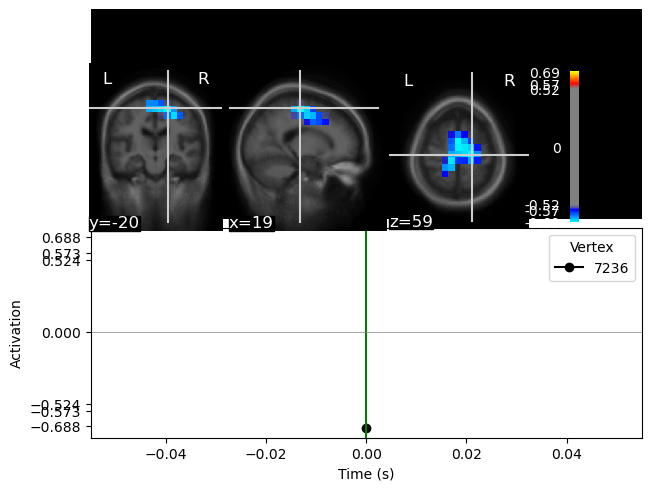

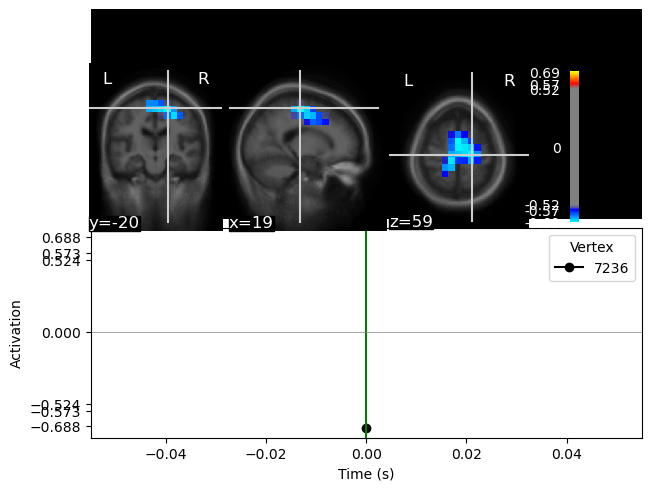

In [3]:
event_name = str(event_id)
duty_cycle = ss['event_name_list'][event_id - 1]
subjects_dir = ss['fs_subjects_dir']
subject = ss['subject_id_list'][subject_index]
print("loading dataset for subject: ", subject)

save_dir = Path(ss['hilbert_ref_dir']) / subject / event_name
save_dir.mkdir(parents=True, exist_ok=True)

# load hilbert stc data
hilbert_stc_file = Path(ss['hilbert_ref_dir']) / subject / event_name / f"{subject}-event-{event_name}-morph-z-vol.stc"
stc = mne.read_source_estimate(hilbert_stc_file)

fsaverage_src_file = Path(ss["fs_subjects_dir"])  / "fsaverage" / "bem" / "fsaverage-vol-10-src.fif"

fsaverage_src = mne.read_source_spaces(str(fsaverage_src_file))

stc.plot(
        src=fsaverage_src,
        subject="fsaverage",
        subjects_dir=ss["fs_subjects_dir"],
        mode="stat_map",            # overlays data on anatomical MRI slices
        verbose=False,
    )

In [4]:
sig_z_stc_fname = "/home/elias/Documents/thesis_intermediate/data/scratch/stc/subject_stat/0005_3SJ-z_val-vol.stc"
sig_z_stc = mne.read_source_estimate(sig_z_stc_fname)